# Expected Points Models by Position

Linear regression models predicting next gameweek's points from:
- Average points per game (season to date)
- Average points per game (last 10 featured games)
- Fixture difficulty (easy/medium/hard)
- Home/Away

Walk-forward validation: GW 28-33 test, GW 1-27+ train (expanding window)

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ML
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

print('Imports successful!')

Imports successful!


## 1. Load Data

In [44]:
# Load all gameweek CSVs
data_dir = Path('data')
csv_files = sorted(data_dir.glob('player_stats_gw*.csv'))

dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)

# Sort by player and gameweek
df = df.sort_values(['player_id', 'gameweek']).reset_index(drop=True)

print(f'Loaded {len(csv_files)} gameweeks')
print(f'Total rows: {len(df):,}')
print(f'Gameweeks: {df["gameweek"].min()}-{df["gameweek"].max()}')
print(f'\nPositions: {df["position"].unique()}')

Loaded 35 gameweeks
Total rows: 83,698
Gameweeks: 1-35

Positions: <StringArray>
['MID', 'GK', 'FWD', 'DEF']
Length: 4, dtype: str


In [45]:
df[df['display_name'] == 'L. Wing'].tail(10)

,player_id,first_name,last_name,display_name,position,squad_id,gameweek,opponent_id,opponent_name,fixture_difficulty,...,penalty_saves,clean_sheet,goals_conceded,clearances,blocks,tackles,interceptions,key_passes,shots_on_target,points
36570,432647,Lewis,Wing,L. Wing,MID,108,29,112,Wycombe,hard,...,0,0,0,0,0,0,2,2,0,10
36571,432647,Lewis,Wing,L. Wing,MID,108,29,30,Bolton,hard,...,0,0,0,0,0,0,4,0,1,11
36572,432647,Lewis,Wing,L. Wing,MID,108,30,50,Port Vale,easy,...,0,0,0,0,0,0,0,2,1,10
36573,432647,Lewis,Wing,L. Wing,MID,108,31,55,Bradford,hard,...,0,0,0,0,0,0,2,2,0,7
36574,432647,Lewis,Wing,L. Wing,MID,108,32,102,Luton,medium,...,0,0,0,0,0,0,2,3,0,10
36575,432647,Lewis,Wing,L. Wing,MID,108,32,77,Mansfield,medium,...,0,0,0,0,0,0,3,0,0,7
36576,432647,Lewis,Wing,L. Wing,MID,108,33,76,Plymouth,medium,...,0,0,0,0,0,0,1,4,0,9
36577,432647,Lewis,Wing,L. Wing,MID,108,33,587,Burton,easy,...,0,0,0,0,0,0,2,1,1,9
36578,432647,Lewis,Wing,L. Wing,MID,108,34,288,Stevenage,hard,...,0,0,0,0,0,0,1,0,0,4
36579,432647,Lewis,Wing,L. Wing,MID,108,35,111,Wigan,easy,...,0,0,0,0,0,0,4,1,1,11


In [46]:
df[df['display_name'] == 'L. Wing']['points'].mean()

np.float64(7.825)

## 2. Build Rolling Features

For each player at gameweek N:
- `avg_pts_season`: mean points in GW 1..N-1 where player featured (mins > 0)
- `avg_pts_last_10`: mean points in last 10 featured games before GW N

In [47]:
# Create a featured-games-only view for rolling calculations
df_featured = df[df['minutes_played'] > 0].copy().sort_values(['player_id', 'gameweek']).reset_index(drop=True)

# For avg_pts_season: cumulative mean of all prior featured games per player
# Must use transform() so the expanding/rolling stays within each player group
df_featured['avg_pts_season'] = df_featured.groupby('player_id')['points'].transform(
    lambda x: x.shift(1).expanding(min_periods=1).mean()
)

# For last-10 avg: rolling mean of last 10 featured games per player
df_featured['avg_pts_last_10'] = df_featured.groupby('player_id')['points'].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=1).mean()
)

# Merge back to main dataframe â€” include opponent_id to avoid cartesian product with multiple games per gameweek
df = df.merge(
    df_featured[['player_id', 'gameweek', 'opponent_id', 'avg_pts_season', 'avg_pts_last_10']],
    on=['player_id', 'gameweek', 'opponent_id'],
    how='left'
)

# For non-featured games, forward-fill season avg (carry previous value), use season avg for last_10 as fallback
df['avg_pts_season'] = df.groupby('player_id')['avg_pts_season'].ffill().fillna(0)
df['avg_pts_last_10'] = df['avg_pts_last_10'].fillna(df['avg_pts_season'])

print(f'\nSample rows with rolling features:')
print(df[['player_id', 'gameweek', 'position', 'points', 'avg_pts_season', 'avg_pts_last_10', 'fixture_difficulty', 'is_home']].head(15))


Sample rows with rolling features:
    player_id  gameweek position  points  avg_pts_season  avg_pts_last_10  \
0        2076        23      MID       0        0.000000         0.000000   
1        3774         1       GK       0        0.000000         0.000000   
2        3774         2       GK       0        0.000000         0.000000   
3        3774         3       GK       0        0.000000         0.000000   
4        3774         4       GK       0        0.000000         0.000000   
5        3774         5       GK       0        0.000000         0.000000   
6        3774         6       GK       3        0.000000         0.000000   
7        3774         7       GK       3        3.000000         3.000000   
8        3774         8       GK       2        3.000000         3.000000   
9        3774         9       GK       7        2.666667         2.666667   
10       3774        10       GK       2        3.750000         3.750000   
11       3774        11       GK       1

## 3. Encode Categorical Features

In [48]:
# Encode fixture difficulty
difficulty_map = {'easy': 0, 'medium': 1, 'hard': 2}
df['fixture_difficulty_encoded'] = df['fixture_difficulty'].map(difficulty_map).fillna(1)  # Default to medium

# Encode is_home (H=1, A=0)
df['is_home_binary'] = (df['is_home'] == 'H').astype(int)

print('Encoded features:')
print(df[['fixture_difficulty', 'fixture_difficulty_encoded', 'is_home', 'is_home_binary']].head(10))

Encoded features:
  fixture_difficulty  fixture_difficulty_encoded is_home  is_home_binary
0               hard                           2       A               0
1             medium                           1       A               0
2               easy                           0       H               1
3               easy                           0       H               1
4               easy                           0       A               0
5               hard                           2       H               1
6               hard                           2       A               0
7               easy                           0       H               1
8             medium                           1       A               0
9               hard                           2       H               1


## 4. Filter to GW 20+ (ensure sufficient history)

In [49]:
# Filter to GW >= 20, featured games only (minutes_played > 0)
# We only train/predict on games where the player actually played.
# Including non-featured rows (0 mins, 0 pts) would teach the model that
# good players regularly score 0, dragging all predictions down.
df_train = df[(df['gameweek'] >= 20) & (df['minutes_played'] > 0)].copy()
df_train = df_train.dropna(subset=['avg_pts_season', 'avg_pts_last_10'])

print(f'Rows with GW >= 20 (featured only): {len(df_train):,}')
print(f'Gameweeks: {df_train["gameweek"].min()}-{df_train["gameweek"].max()}')
print(f'Positions: {df_train["position"].unique()}')

Rows with GW >= 20 (featured only): 21,371
Gameweeks: 20-35
Positions: <StringArray>
['GK', 'FWD', 'DEF', 'MID']
Length: 4, dtype: str


## 5. Walk-Forward Validation (GW 28-33)

For each test gameweek, train on all prior data and predict that gameweek

In [50]:
test_gws = [28, 29, 30, 31, 32, 33]
positions = ['GK', 'DEF', 'MID', 'FWD']

# Storage for results
all_predictions = []
all_actuals = []
model_results = {}

for position in positions:
    print(f'\n=== {position} ===')
    model_results[position] = {'baseline': [], 'full': []}
    
    for test_gw in test_gws:
        # Split: train on all data before test_gw
        train_data = df_train[(df_train['gameweek'] < test_gw) & (df_train['position'] == position)]
        test_data = df_train[(df_train['gameweek'] == test_gw) & (df_train['position'] == position)]
        
        if len(train_data) == 0 or len(test_data) == 0:
            print(f'  GW {test_gw}: Skipped (insufficient data)')
            continue
        
        # Features
        X_train_full = train_data[['avg_pts_season', 'avg_pts_last_10', 'fixture_difficulty_encoded', 'is_home_binary']]
        X_train_base = train_data[['avg_pts_season']]
        y_train = train_data['points']
        
        X_test_full = test_data[['avg_pts_season', 'avg_pts_last_10', 'fixture_difficulty_encoded', 'is_home_binary']]
        X_test_base = test_data[['avg_pts_season']]
        y_test = test_data['points']
        
        # Train baseline (avg_pts_season only)
        model_base = LinearRegression()
        model_base.fit(X_train_base, y_train)
        y_pred_base = model_base.predict(X_test_base)
        mae_base = mean_absolute_error(y_test, y_pred_base)
        mse_base = mean_squared_error(y_test, y_pred_base)
        rmse_base = np.sqrt(mse_base)
        r2_base = r2_score(y_test, y_pred_base)
        
        # Train full model
        model_full = LinearRegression()
        model_full.fit(X_train_full, y_train)
        y_pred_full = model_full.predict(X_test_full)
        mae_full = mean_absolute_error(y_test, y_pred_full)
        mse_full = mean_squared_error(y_test, y_pred_full)
        rmse_full = np.sqrt(mse_full)
        r2_full = r2_score(y_test, y_pred_full)
        
        # Store results
        model_results[position]['baseline'].append({'gw': test_gw, 'mae': mae_base, 'mse': mse_base, 'rmse': rmse_base, 'r2': r2_base})
        model_results[position]['full'].append({'gw': test_gw, 'mae': mae_full, 'mse': mse_full, 'rmse': rmse_full, 'r2': r2_full})
        
        print(f'  GW {test_gw} (train: {len(train_data)}, test: {len(test_data)})')
        print(f'    Baseline - MAE: {mae_base:.3f}, RMSE: {rmse_base:.3f}, RÃ‚Â²: {r2_base:.3f}')
        print(f'    Full     - MAE: {mae_full:.3f}, RMSE: {rmse_full:.3f}, RÃ‚Â²: {r2_full:.3f}')
        
        # Collect for aggregate metrics
        all_predictions.append(y_pred_full)
        all_actuals.append(y_test.values)

print('\nWalk-forward validation complete!')


=== GK ===
  GW 28 (train: 681, test: 92)
    Baseline - MAE: 2.811, RMSE: 3.394, RÃ‚Â²: -0.009
    Full     - MAE: 2.733, RMSE: 3.322, RÃ‚Â²: 0.033
  GW 29 (train: 773, test: 102)
    Baseline - MAE: 2.335, RMSE: 2.795, RÃ‚Â²: -0.000
    Full     - MAE: 2.323, RMSE: 2.785, RÃ‚Â²: 0.007
  GW 30 (train: 875, test: 106)
    Baseline - MAE: 2.398, RMSE: 2.779, RÃ‚Â²: -0.060
    Full     - MAE: 2.400, RMSE: 2.792, RÃ‚Â²: -0.070
  GW 31 (train: 981, test: 90)
    Baseline - MAE: 2.191, RMSE: 2.703, RÃ‚Â²: -0.006
    Full     - MAE: 2.186, RMSE: 2.677, RÃ‚Â²: 0.013
  GW 32 (train: 1071, test: 115)
    Baseline - MAE: 2.293, RMSE: 2.766, RÃ‚Â²: -0.015
    Full     - MAE: 2.346, RMSE: 2.782, RÃ‚Â²: -0.027
  GW 33 (train: 1186, test: 125)
    Baseline - MAE: 2.444, RMSE: 2.905, RÃ‚Â²: -0.008
    Full     - MAE: 2.447, RMSE: 2.881, RÃ‚Â²: 0.009

=== DEF ===
  GW 28 (train: 3432, test: 468)
    Baseline - MAE: 2.798, RMSE: 3.221, RÃ‚Â²: 0.059
    Full     - MAE: 2.703, RMSE: 3.134, RÃ‚Â²: 0.109


## 6. Aggregate Results

In [51]:
# Combine all predictions and actuals
all_preds = np.concatenate(all_predictions)
all_acts = np.concatenate(all_actuals)

# Aggregate metrics
results_rows = []

for position in positions:
    for model_type in ['baseline', 'full']:
        results = model_results[position][model_type]
        if len(results) == 0:
            continue
        
        mae = np.mean([r['mae'] for r in results])
        mse = np.mean([r['mse'] for r in results])
        rmse = np.mean([r['rmse'] for r in results])
        r2 = np.mean([r['r2'] for r in results])
        
        results_rows.append({
            'Position': position,
            'Model': model_type.capitalize(),
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'RÃ‚Â²': r2
        })

results_df = pd.DataFrame(results_rows)

print('\n=== AGGREGATE RESULTS (GW 28-33) ===')
print(results_df.to_string(index=False))

# Overall metrics
mae_all = mean_absolute_error(all_acts, all_preds)
mse_all = mean_squared_error(all_acts, all_preds)
rmse_all = np.sqrt(mse_all)
r2_all = r2_score(all_acts, all_preds)

print(f'\n=== OVERALL (Full Model, All Positions, GW 28-33) ===')
print(f'MAE:  {mae_all:.3f}')
print(f'MSE:  {mse_all:.3f}')
print(f'RMSE: {rmse_all:.3f}')
print(f'RÃ‚Â²:   {r2_all:.3f}')


=== AGGREGATE RESULTS (GW 28-33) ===
Position    Model      MAE       MSE     RMSE       RÃ‚Â²
      GK Baseline 2.412129  8.408644 2.890380 -0.016289
      GK     Full 2.405889  8.299096 2.873196 -0.005666
     DEF Baseline 2.752173 11.249472 3.350170  0.047707
     DEF     Full 2.710925 11.016165 3.314399  0.068091
     MID Baseline 2.397633 10.161953 3.187065  0.061472
     MID     Full 2.399518 10.132234 3.182448  0.064090
     FWD Baseline 2.233150  9.782732 3.123080  0.050324
     FWD     Full 2.202449  9.620857 3.097278  0.065728

=== OVERALL (Full Model, All Positions, GW 28-33) ===
MAE:  2.450
MSE:  10.171
RMSE: 3.189
RÃ‚Â²:   0.080


## 7. Visualisation: Predicted vs Actual by Position

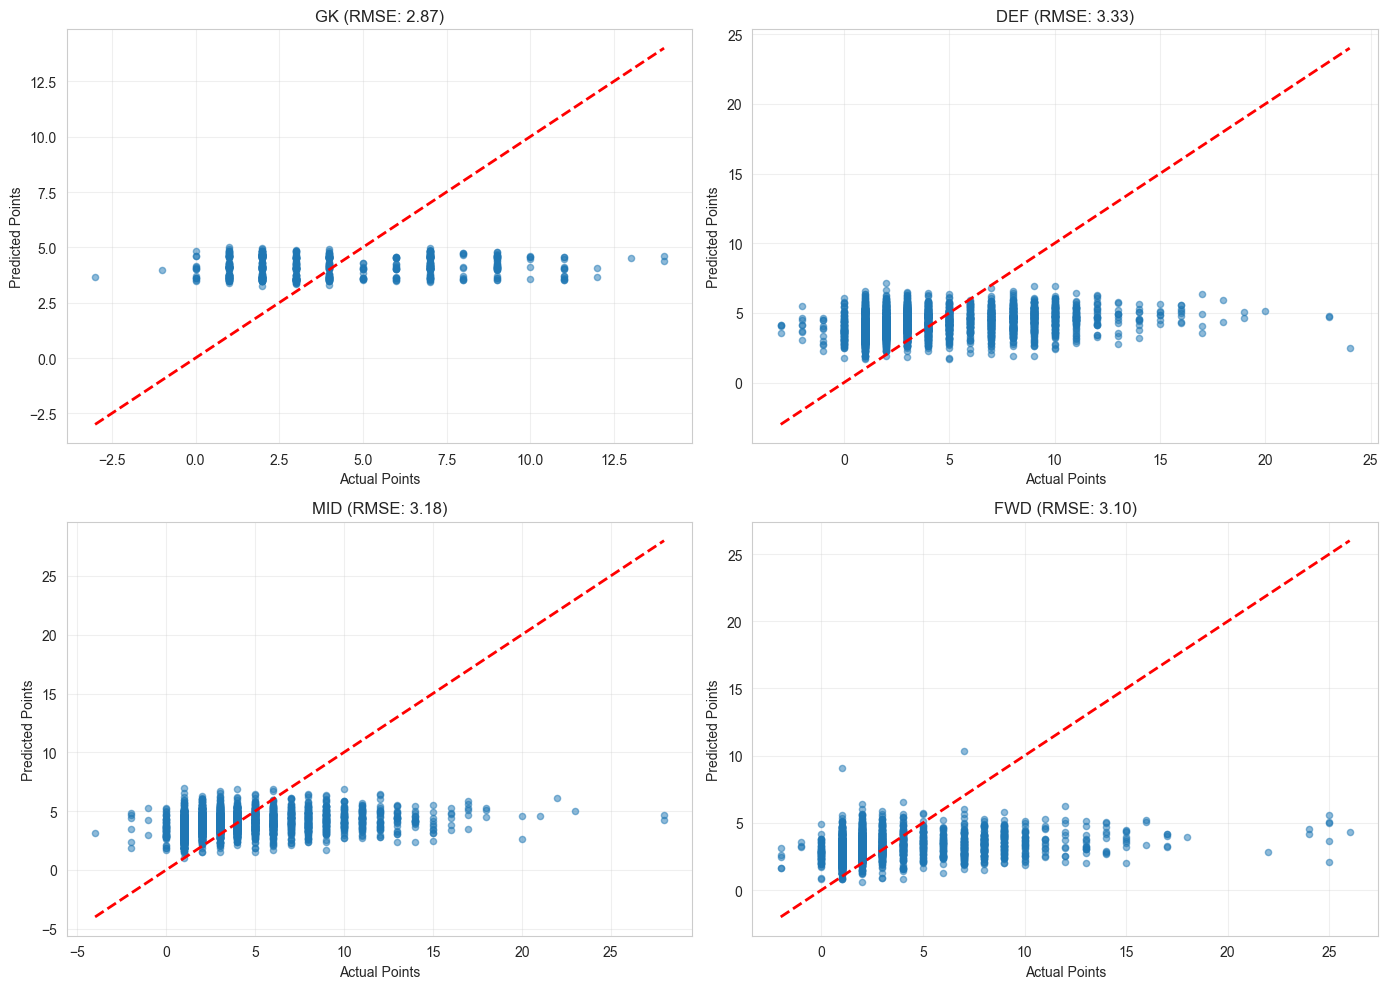

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, position in enumerate(positions):
    # Collect all predictions and actuals for this position across walk-forward folds
    position_preds = []
    position_acts = []
    
    for test_gw in test_gws:
        train_data = df_train[(df_train['gameweek'] < test_gw) & (df_train['position'] == position)]
        test_data = df_train[(df_train['gameweek'] == test_gw) & (df_train['position'] == position)]
        
        if len(train_data) == 0 or len(test_data) == 0:
            continue
        
        X_train = train_data[['avg_pts_season', 'avg_pts_last_10', 'fixture_difficulty_encoded', 'is_home_binary']]
        y_train = train_data['points']
        X_test = test_data[['avg_pts_season', 'avg_pts_last_10', 'fixture_difficulty_encoded', 'is_home_binary']]
        y_test = test_data['points']
        
        model = LinearRegression().fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        position_preds.extend(y_pred)
        position_acts.extend(y_test.values)
    
    if len(position_preds) == 0:
        continue
    
    position_preds = np.array(position_preds)
    position_acts = np.array(position_acts)
    
    ax = axes[idx]
    ax.scatter(position_acts, position_preds, alpha=0.5, s=20)
    ax.plot([position_acts.min(), position_acts.max()], [position_acts.min(), position_acts.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Points')
    ax.set_ylabel('Predicted Points')
    ax.set_title(f'{position} (RMSE: {np.sqrt(mean_squared_error(position_acts, position_preds)):.2f})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Feature Comparison: Improvement from Full vs Baseline

In [53]:
comparison_rows = []

for position in positions:
    baseline_rmses = [r['rmse'] for r in model_results[position]['baseline']]
    full_rmses = [r['rmse'] for r in model_results[position]['full']]
    
    if len(baseline_rmses) == 0:
        continue
    
    avg_baseline_rmse = np.mean(baseline_rmses)
    avg_full_rmse = np.mean(full_rmses)
    improvement = ((avg_baseline_rmse - avg_full_rmse) / avg_baseline_rmse) * 100
    
    comparison_rows.append({
        'Position': position,
        'Baseline RMSE': avg_baseline_rmse,
        'Full RMSE': avg_full_rmse,
        'Improvement %': improvement
    })

comparison_df = pd.DataFrame(comparison_rows)

print('\n=== IMPROVEMENT: Full Model vs Baseline ===')
print(comparison_df.to_string(index=False))
print(f'\nAverage improvement: {comparison_df["Improvement %"].mean():.2f}%')


=== IMPROVEMENT: Full Model vs Baseline ===
Position  Baseline RMSE  Full RMSE  Improvement %
      GK       2.890380   2.873196       0.594545
     DEF       3.350170   3.314399       1.067740
     MID       3.187065   3.182448       0.144865
     FWD       3.123080   3.097278       0.826184

Average improvement: 0.66%


## 9. Case Study: Lewis Wing Predictions (GW 28-33)

## Helper: Player Prediction Function

In [54]:
def player_predictions(player_name, test_gws=[28, 29, 30, 31, 32, 33]):
    """
    Generate and display predictions for a player across test gameweeks.
    
    Args:
        player_name: Display name of player (e.g., 'L. Wing')
        test_gws: List of gameweeks to predict for
    """
    # Find player
    player_data = df_train[df_train['display_name'].str.contains(player_name, case=False, na=False)]
    
    if len(player_data) == 0:
        print(f'Player "{player_name}" not found')
        return
    
    player_id = player_data['player_id'].iloc[0]
    position = player_data['position'].iloc[0]
    full_name = player_data['display_name'].iloc[0]
    
    print(f'Found: {full_name} (ID: {player_id}, Position: {position})\n')
    
    # Get player's test data (GW 28-33)
    player_test = df_train[(df_train['player_id'] == player_id) & (df_train['gameweek'].isin(test_gws))]
    
    if len(player_test) == 0:
        print('No data for test gameweeks')
        return
    
    # Train model on his position for GW 1-27
    train_data = df_train[(df_train['gameweek'] < 28) & (df_train['position'] == position)]
    X_train = train_data[['avg_pts_season', 'avg_pts_last_10', 'fixture_difficulty_encoded', 'is_home_binary']]
    y_train = train_data['points']
    
    model = LinearRegression().fit(X_train, y_train)
    
    # Get predictions
    X_player = player_test[['avg_pts_season', 'avg_pts_last_10', 'fixture_difficulty_encoded', 'is_home_binary']]
    y_pred = model.predict(X_player)
    y_actual = player_test['points'].values
    
    # Build results table
    results = []
    for idx, (_, row) in enumerate(player_test[['gameweek', 'opponent_name', 'fixture_difficulty', 'is_home', 'avg_pts_season', 'avg_pts_last_10', 'points']].iterrows()):
        results.append({
            'GW': int(row['gameweek']),
            'Opponent': row['opponent_name'],
            'Fixture': row['fixture_difficulty'],
            'H/A': row['is_home'],
            'Avg Pts (Season)': f"{row['avg_pts_season']:.2f}",
            'Avg Pts (Last 6)': f"{row['avg_pts_last_10']:.2f}",
            'Predicted': f"{y_pred[idx]:.1f}",
            'Actual': int(row['points'])
        })
    
    results_df = pd.DataFrame(results)
    
    print(f'=== {full_name}: Predictions GW 28-33 ===')
    print(results_df.to_string(index=False))
    
    # Summary metrics
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    
    print(f'\nMAE:  {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'Total predicted: {y_pred.sum():.0f}')
    print(f'Total actual:    {y_actual.sum()}')

# Example usage:
player_predictions('L. Wing')

Found: L. Wing (ID: 432647, Position: MID)

=== L. Wing: Predictions GW 28-33 ===
 GW  Opponent Fixture H/A Avg Pts (Season) Avg Pts (Last 6) Predicted  Actual
 28   AFC Wim  medium   A             7.64             7.90       5.9       2
 28     Wigan    easy   A             7.45             7.90       6.0       9
 29   Wycombe    hard   H             7.50             7.30       5.8      10
 29    Bolton    hard   H             7.58             6.40       5.6      11
 30 Port Vale    easy   A             7.69             7.10       5.9      10
 31  Bradford    hard   H             7.76             7.80       6.0       7
 32     Luton  medium   A             7.74             7.60       5.9      10
 32 Mansfield  medium   A             7.80             8.40       6.1       7
 33  Plymouth  medium   H             7.78             8.50       6.4       9
 33    Burton    easy   A             7.81             8.60       6.3       9

MAE:  3.18
RMSE: 3.46
Total predicted: 60
Total actual:    

In [55]:
player_predictions('S. Bradley')

Found: S. Bradley (ID: 90495, Position: DEF)

=== S. Bradley: Predictions GW 28-33 ===
 GW     Opponent Fixture H/A Avg Pts (Season) Avg Pts (Last 6) Predicted  Actual
 28     Plymouth  medium   A             6.46             6.60       5.1       3
 29       Bolton    hard   H             6.34             6.60       4.8       3
 29  Northampton    easy   H             6.23             5.80       5.7       8
 30    Mansfield  medium   A             6.29             6.00       4.9       9
 31    Blackpool    easy   H             6.38             5.80       5.8       9
 32      Cardiff    hard   A             6.45             6.00       4.4       9
 32       Exeter    easy   A             6.53             6.60       5.7       8
 33    Stockport    hard   H             6.57             7.10       5.0       9
 33 Huddersfield  medium   A             6.64             7.50       5.4       3

MAE:  2.98
RMSE: 3.13
Total predicted: 47
Total actual:    61


In [60]:
int_predictions('O. Norwood')

=== O. Norwood: Interceptions Predictions (GW 28-33) ===
    Assumed minutes: 90

 GW    Opponent H/A Int/90 (Szn) Int/90 (L10) Opp Conc  Mins Pred (90m) Pred (actual m)  Actual Pts (90m) Pts (actual)
 28    L Orient   H         1.61         1.35     0.63    90       1.12            1.12       0       2.2            0
 29    Bradford   A         1.54         1.23     0.58    90       1.04            1.04       0       2.1            0
 30       Wigan   H         1.48         1.13     0.61    90       1.06            1.06       1       2.1            2
 30      Burton   A         1.46         1.23     0.57    75       1.04            0.88       0       2.1            0
 31   Stevenage   A         1.41         1.13     0.58    90       1.01            1.01       2       2.0            4
 33     Lincoln   A         1.43         1.33     0.53    90       0.99            0.99       0       2.0            0
 33 Northampton   H         1.38         1.13     0.42    90       0.89            0.